# Predictive Modeling

## Prepare my workspace

In [77]:
# Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sms
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
# Load the data
reg_df = pd.read_csv(r"D:\Data science project\Data science\Codveda-internship\Level 1\Task 2\processed_real_estate.csv")

# preview the data
print("Real estates data:\n")
reg_df

Real estates data:



,name,sqm,year_built,Price(EGP),Price/Sqm,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,...,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price),log(price/sqm),Is log(price/sqm) outlier,Is log(sqm) outlier,Is log(price) outlier,Is FloorNumber outlier
0,Alamain (Latin District),92.86,2025,6594000,71010.1228,1,1,0,0,1,...,0,0,0,4.531093,15.701671,11.170578,False,False,False,False
1,Beachfront Tower - B1,398.00,2025,66104000,166090.4523,0,0,0,0,1,...,0,0,0,5.986452,18.006740,12.020288,False,False,True,False
2,PODIA,93.00,2025,12824000,137892.4731,0,1,1,0,1,...,1,0,0,4.532599,16.366829,11.834229,False,False,False,True
3,Mazarine Apartment,252.00,2025,12857000,51019.8413,1,1,0,0,0,...,0,0,0,5.529429,16.369399,10.839970,False,False,False,False
4,Alamain (Latin District),209.42,2025,8721000,41643.5870,1,1,0,0,1,...,0,0,0,5.344342,15.981244,10.636903,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,Alamain (Latin District),177.47,2025,5678000,31994.1399,1,1,0,0,1,...,0,0,0,5.178802,15.552110,10.373308,False,False,False,False
852,Jade Park,692.00,2025,25292000,36549.1329,1,0,1,1,0,...,0,0,0,6.539586,17.045999,10.506413,False,True,False,False
853,Mamsha Avenue,171.00,2025,6137000,35888.8889,1,1,0,0,1,...,0,0,0,5.141664,15.629847,10.488183,False,False,False,False
854,Alamain (Latin District),207.58,2025,5933000,28581.7516,1,1,0,0,1,...,0,0,0,5.335517,15.596041,10.260524,False,False,False,False


## Regression

### Pick the wanted features only

In [79]:
drop_cols = ["sqm","Price(EGP)","Price/Sqm",
             "year_built","FloorNumber","BuildingNumber",
             "UnitNumber","Is FloorNumber outlier","LowFloor",
             "Bedroom_0","Bathroom_0","city_Cairo",
             "governorate_Cairo","propertyCategory_Residential",
             "propertySubType_Apartment","log(price/sqm)","city_Mersa Matruh",
             "governorate_Matrouh","governorate_Alexandria","governorate_Dakahlia"] # The unnecessary columns, and first dummy from every categorical column of dummies for full rank dummies, Dropping log(price/sqm) because it has the dependent variable. Dropping governorate Matrouh because I have two values of Matrouh with different columns
reg_df = reg_df.drop(drop_cols, axis=1) # drop these columns
outliers_bool = ["Is log(price) outlier", "Is log(price/sqm) outlier", "Is log(sqm) outlier"] # outliers boolean columns
outliers_mask = reg_df[outliers_bool].max(axis=1) # Split outliers from non-outliers
non_outliers_df = reg_df[~ outliers_mask].drop(outliers_bool, axis =1) # the non outliers rows
outliers_df = reg_df[outliers_mask].drop(outliers_bool, axis = 1) # the outlier values

non_outliers_df

,name,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,...,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm),log(price)
0,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,1,0,0,0,0,0,0,4.531093,15.701671
2,PODIA,0,1,1,0,1,1,0,0,0,...,0,0,0,1,0,1,0,0,4.532599,16.366829
3,Mazarine Apartment,1,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,5.529429,16.369399
4,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,5.344342,15.981244
5,Latin City,0,1,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,4.934474,15.715825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,T- Residences,1,1,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,4.867534,14.796937
850,Alamain (Latin District),1,1,0,0,1,0,1,1,1,...,0,1,0,0,0,0,0,0,4.835567,15.731256
851,Alamain (Latin District),1,1,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,5.178802,15.552110
853,Mamsha Avenue,1,1,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,5.141664,15.629847


### Non-outliers regression

In [80]:
def set_xy(data, outliers:bool=False):
    """Set x, and y data

    Args:
        data (pd.DataFrame): The data of y, and x
        outliers(bool): Outliers data or non_outliers data
    """
    try:
        outliers_bool = ["Is log(price) outlier", "Is log(price/sqm) outlier", "Is log(sqm) outlier"] # outliers boolean columns
        outliers_mask = data[outliers_bool].max(axis=1) # Split outliers from non-outliers
        
        if outliers:
            # Set X, and y
            data = data[outliers_mask].drop(outliers_bool, axis =1)
            x = data.drop(["name","log(price)"],axis= 1)
            y = data["log(price)"]
            return x,y
        else:
            data = data[~ outliers_mask].drop(outliers_bool, axis =1)
            x = data.drop(["name","log(price)"], axis = 1)
            y = data["log(price)"]
            return x,y
    except:
         # Set X, and y
        x = data.drop("log(price)",axis= 1)
        y = data["log(price)"]
        return x,y

def split_data(X,y, test_size:float = 0.2):
    """Split the data into train, and test data

    Args:
        X (DataFrame): X matrix
        y (array_like): The dependent variable
        test_size (float, optional): The percentage of test rows of the data. Defaults to 0.2.

    Returns:
        X_train, X_test, y_train, y_test: Return the train, and test data
    """
    # Split into train, and test data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42) # test data is 20% of the data which equals 146 row
    return [X_train, X_test, y_train, y_test]

x,y = set_xy(reg_df)
X_train, X_test, y_train, y_test = split_data(x,y)

x

,has_main_facilities,has_security_features,has_parking_safety,has_building_facilities,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,...,city_New Administrative Capital,city_New Cairo,city_North Coast,city_Old Cairo,propertyCategory_Commercial,propertySubType_Attached Houses,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm)
0,1,1,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,4.531093
2,0,1,1,0,1,1,0,0,0,1,...,0,0,0,0,1,0,1,0,0,4.532599
3,1,1,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,5.529429
4,1,1,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,5.344342
5,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,4.934474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,1,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,4.867534
850,1,1,0,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,4.835567
851,1,1,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,5.178802
853,1,1,0,0,1,0,1,0,1,1,...,1,0,0,0,0,0,0,0,0,5.141664


#### Make the original model

In [81]:
org_reg_model = LinearRegression().fit(X_train, y_train) # fit the model

def reg_summary(X_train, y_train):
    """Return the statsmodels model summary

    Args:
        X_train (DataFrame): X train matrix
        y_train (Array_like): Dependent variable
    Returns:
        Model_summary: Return the model summary(F-statistic, R-squared, etc.)
    """
### See the summary of the model using statsmodels

    reg_sms = sms.OLS(y_train, sms.add_constant(X_train)).fit()
    results = reg_sms.summary2()

    print(f"The regression model summary:\n{results}")
    
reg_summary(X_train,y_train)

The regression model summary:
                         Results: Ordinary least squares
Model:                   OLS                   Adj. R-squared:          0.793    
Dependent Variable:      log(price)            AIC:                     -49.0950 
Date:                    2025-10-31 17:19      BIC:                     82.0533  
No. Observations:        585                   Log-Likelihood:          54.548   
Df Model:                29                    F-statistic:             78.15    
Df Residuals:            555                   Prob (F-statistic):      3.38e-175
R-squared:               0.803                 Scale:                   0.051215 
---------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
---------------------------------------------------------------------------------
const                             10.7057   0.3241 33.0351 0.0000 10.0692 11.3423
has_main_fa

Model overall statistically strong:
- F-statistic: 77.83, p-value: 0.00 --> At least one of them effect on log(price)
- R-squared: 0.814, Adj. R-squared: 0.803 --> The model explained 80% of the data which is good
- AIC, BIC: -49.1556, 99.7359 both looks fine
- Skew: 0.003(roughly normal), Kurtosis: 3.169(Roughly normal)
-JB: 0.695, p-value: 0.707 --> Fail to reject normality of residuals
- Condition Number: 368 which slightly good

> Solution: Center log(sqm), Drop one of governorate or city, Add the square of sqm because of non-linear relationship between them, Add interaction like has_modern, has main facilities, etc.

In [82]:
reg_df["log(sqm)_centered"] = reg_df["log(sqm)"] - x["log(sqm)"].mean() # center log(sqm)

reg_df["log(sqm) centered ** 2"] = reg_df["log(sqm)_centered"] ** 2 # centered log(sqm) ^2

reg_df.drop("log(sqm)",axis = 1, inplace=True) # drop log(sqm)

reg_df["has_full_facilities"] = reg_df["has_main_facilities"] * reg_df["has_building_facilities"] # combine them together, and drop them, because Building facilities, and main facilities are important
reg_df["has_full_facilities * modern"] = reg_df["has_full_facilities"] * reg_df["has_modern"] # full_facilities * modern
reg_df.drop(["has_main_facilities","has_building_facilities"], axis =1, inplace=True)

x,y = set_xy(reg_df)
X_train, X_test, y_train, y_test = split_data(x, y) # split the new data
reg_summary(X_train,y_train) # see the new model summary

The regression model summary:
                         Results: Ordinary least squares
Model:                    OLS                   Adj. R-squared:          0.788    
Dependent Variable:       log(price)            AIC:                     -34.7910 
Date:                     2025-10-31 17:19      BIC:                     100.7290 
No. Observations:         585                   Log-Likelihood:          48.395   
Df Model:                 30                    F-statistic:             73.46    
Df Residuals:             554                   Prob (F-statistic):      9.50e-172
R-squared:                0.799                 Scale:                   0.052398 
----------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
----------------------------------------------------------------------------------
const                             16.1468   0.1284 125.7146 0.0000 15.8945 16.3991


That's better now CN: 369 which is very good

#### Model selection using General to specific method

In [83]:
def general_to_specific(df, y_col, x_cols, pval_threshold=0.05, vif_threshold=10.0,
                        correction='fdr_bh', verbose=True):
    """
    General-to-Specific model selection using corrected p-values and VIF reduction.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing dependent and independent variables.
    y_col : str
        Dependent variable name.
    x_cols : list
        Initial list of independent variable names.
    pval_threshold : float
        Threshold for corrected p-values (default = 0.05).
    vif_threshold : float
        Threshold for Variance Inflation Factor (default = 10).
    correction : str
        Type of p-value correction ('bonferroni', 'fdr_bh', etc.).
    verbose : bool
        Whether to print progress.

    Returns
    -------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Final OLS model.
    removed_vars : list
        Variables removed during the selection process.
    Final_vifs: list
        the final vifs values
    """
    removed_vars = []
    current_x = x_cols.copy()

    while True:
        X = sms.add_constant(df[current_x])
        y = df[y_col]
        model = sms.OLS(y, X).fit()

        # 1️⃣ Corrected p-values
        pvals = model.pvalues.drop('const', errors='ignore')
        _, corrected_pvals, _, _ = multipletests(pvals, method=correction)
        corrected = pd.Series(corrected_pvals, index=pvals.index)

        worst_p = corrected.max()
        worst_var_p = corrected.idxmax()

        # 2️⃣ VIF calculation
        vif_df = pd.DataFrame({
            'Variable': current_x,
            'VIF': [variance_inflation_factor(X.values, i+1) for i in range(len(current_x))]
        })
        worst_vif = vif_df['VIF'].max()
        try: # To avoid infinity floats
            worst_vif_int = int(worst_vif)
        except: worst_vif_int = worst_vif
        worst_var_vif = vif_df.loc[vif_df['VIF'].idxmax(), 'Variable']

        # 3️⃣ Decide what to remove
        if worst_p > pval_threshold or worst_vif_int > vif_threshold:
            if worst_p > pval_threshold:
                worst_var = worst_var_p
                reason = f"corrected p={worst_p:.4f}"
            elif worst_vif > vif_threshold:
                worst_var = worst_var_vif
                reason = f"VIF {worst_vif:.2f}"
            else:
                break  # Should not happen, but handle the case

            if verbose:
                print(f"Removing {worst_var} due to {reason}")
            current_x = [v for v in current_x if v != worst_var]
            removed_vars.append(worst_var)
        else:
            if verbose:
                print("No variable exceeds corrected p-value or VIF threshold. Selection complete.")
                break

    # Final VIFs for sanity check
    final_X = sms.add_constant(df[current_x])
    final_vif = pd.DataFrame({
        'Variable': current_x,
        'VIF': [variance_inflation_factor(final_X.values, i+1) for i in range(len(current_x))]
    })

    if verbose:
        print("\nFinal VIFs:")
        print(final_vif.sort_values('VIF', ascending=False).to_string(index=False))
        print(f"The final model summary:\n{model.summary2()}")
    return model, removed_vars, final_vif


df = X_train.join(y_train)
final_model, removed_vars, final_vif = general_to_specific(df, "log(price)", X_train.columns)
X_train = X_train.drop(removed_vars, axis = 1)
X_test = X_test.drop(removed_vars, axis =1)

Removing propertySubType_Others(very rare) due to corrected p=0.9858
Removing has_facilities due to corrected p=0.8136
Removing propertySubType_Retail due to corrected p=0.7692
Removing has_security_features due to corrected p=0.5952
Removing Bathroom_2 due to corrected p=0.5538
Removing has_other_features due to corrected p=0.3636
Removing log(sqm) centered ** 2 due to corrected p=0.3942
Removing propertySubType_Office due to corrected p=0.2689
Removing MidFloor due to corrected p=0.3109
Removing city_North Coast due to corrected p=0.0760
Removing Bedroom_3 due to VIF 32.57
Removing has_full_facilities * modern due to corrected p=0.4992
No variable exceeds corrected p-value or VIF threshold. Selection complete.

Final VIFs:
                       Variable      VIF
                  city_Mansoura 8.197467
              has_water_feature 5.877457
propertySubType_Attached Houses 5.732800
              log(sqm)_centered 5.135080
city_New Administrative Capital 4.811544
                   

#### Fit the final model

In [84]:
sklearn_model = LinearRegression().fit(X_train, y_train)
sklearn_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- That's better, I should do the RESET to check the linearity, and residuals, and y_pred plot

F-stat: 2.388, p-value: 0.1229


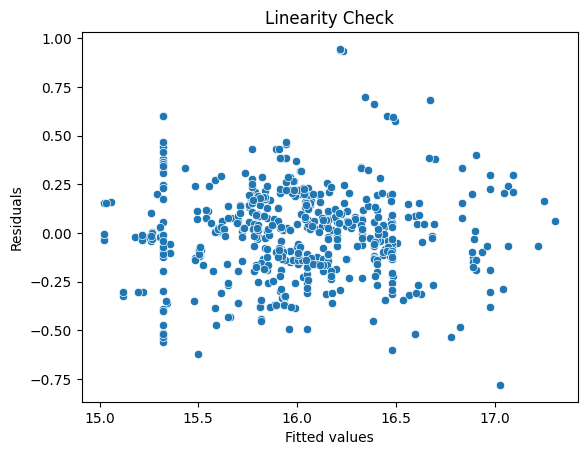

In [85]:
reset_test_results = linear_reset(final_model, power=2, use_f = True) # RESET test
print(f"F-stat: {reset_test_results.fvalue:.3f}, p-value: {reset_test_results.pvalue:.4f}")

### Store y_pred, and residuals to plot the scatterplot
y_pred = final_model.fittedvalues
residuals = final_model.resid

sns.scatterplot(x=y_pred, y=residuals);
plt.title("Linearity Check")
plt.xlabel("Fitted values")
plt.ylabel("Residuals");

Fail to reject the normality of residuals, model is well-specified. Linearity assumptions like residuals are random aren't violated

#### Model metrics

Final model metrics:
MAE     0.171988
RMSE    0.228027
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.7306664  0.76777761 0.78591798 0.74898361 0.7412834 ]


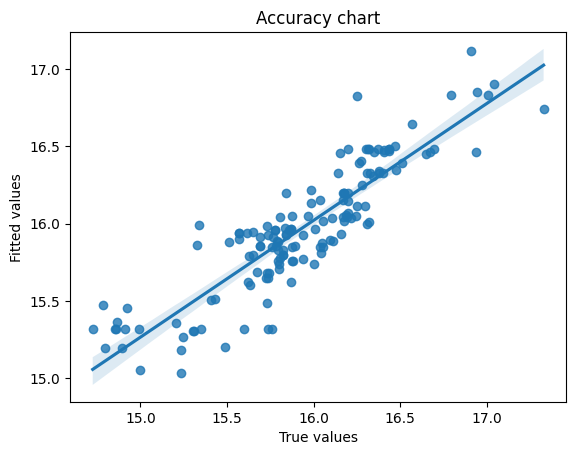

In [86]:
def model_performance(y_pred, y_test, X_train, y_train, estimator):
    """Shows the MAE, RMSE, Accuracy Chart(fitted, True), and cross validation scores(cv=5)

    Args:
        y_pred (array_like): The fitted values 
        y_test (array_like): The true values
        estimator (Model): The fitted model
    """

    mae = mean_absolute_error(y_test, y_pred) # MAE value
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # RMSE value
    # metics series
    metrics = pd.Series({
        "MAE": mae,
        "RMSE": rmse,
    }, name="Metrics")

    # plot the y_true vs. y_pred
    sns.regplot(x=y_test, y=y_pred)
    plt.title("Accuracy chart")
    plt.xlabel("True values")
    plt.ylabel("Fitted values")

    print(f"Final model metrics:\n{metrics}")
    cross_val_scores = cross_val_score(estimator, X_train, y_train, cv=5) # cross validation scores of the seen data
    print(f"Cross validation score of the seen data:\n{cross_val_scores}")
y_pred = sklearn_model.predict(X_test)
model_performance(y_pred, y_test, X_train, y_train, sklearn_model)

MAE, RMSE are close. MAE, RMSE values are very good, indicating approx average range between 0.172 - 0.228 is error in the predicted value

> Our model is stable across different samples

#### Experimental with multiple models

Decision Tree Performance:
Final model metrics:
MAE     0.146125
RMSE    0.241498
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.6738015  0.78189005 0.84325551 0.7481576  0.75292481]


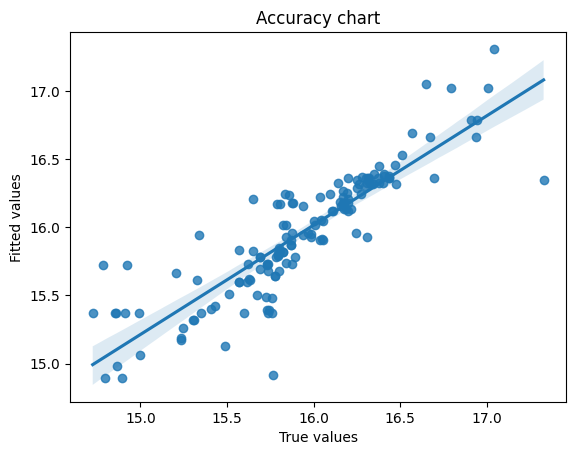

In [87]:
def decision_tree(X_train,X_test, y_test):
    """Perform a decision tree for comparing

    Args:
        X_train (array_like): the seen x data
        X_test (array_like): the unseen x data
        y_test (array_like): the actual y data
    Returns:
        Decision Tree model: The final fitted model
    """

    # Decision Tree
    dt_model = DecisionTreeRegressor(random_state=42)

    dt_model.fit(X_train, y_train)

    dt_predictions = dt_model.predict(X_test)

    print("Decision Tree Performance:")
    model_performance(dt_predictions, y_test, X_train, y_train, dt_model)
    
    return dt_model
dt_model = decision_tree(X_train,X_test, y_test)


Random Forest Performance:
Final model metrics:
MAE     0.129180
RMSE    0.203322
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.72612306 0.84274573 0.82098477 0.79896331 0.79140761]


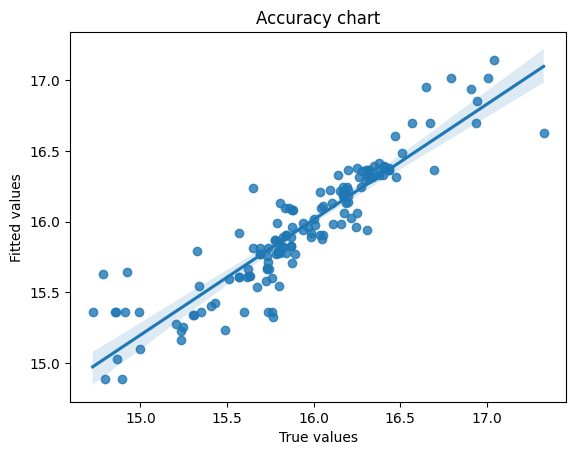

In [88]:
def random_forest(X_train, X_test, y_test):
    """Perform a Random Forest for comparing

    Args:
        X_train (array_like): the seen x data
        X_test (array_like): the unseen x data
        y_test (array_like): the actual y data
    Returns:
        Random Forest model: The final fitted model
    """
    # Random Forest
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)
    print("\nRandom Forest Performance:")
    model_performance(rf_predictions, y_test, X_train, y_train, rf_model)
    return rf_model

rf_model = random_forest(X_train, X_test, y_test)

- RandomForest model is a Stable model with lower errors in the middle of the chart, and the higher errors on the sides of the chart(right, and left). Overall the model is  great

- DecisionTree model is a Stable model with the same shape of the RandomForest. Overall the model is good

- LinearRegression model is a Stable mode, low variance. Overall the model is very good


> The best one is RandomForest model, due to it have the lowest MAE, RMSE

### Outliers regression

#### Set x,y

In [89]:
x,y = set_xy(reg_df, True) # set x, y


X_train, X_test, y_train, y_test = split_data(x,y, 0.081) # split the data into train, and test data(test_data = 10 rows)

reg_summary(X_train, y_train) # Show the model summary

The regression model summary:
                        Results: Ordinary least squares
Model:                    OLS                  Adj. R-squared:         0.983    
Dependent Variable:       log(price)           AIC:                    -140.0608
Date:                     2025-10-31 17:19     BIC:                    -80.0582 
No. Observations:         113                  Log-Likelihood:         92.030   
Df Model:                 21                   F-statistic:            301.9    
Df Residuals:             91                   Prob (F-statistic):     8.76e-75 
R-squared:                0.986                Scale:                  0.014261 
--------------------------------------------------------------------------------
                                   Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
--------------------------------------------------------------------------------
const                              7.8841   0.1154 68.3357 0.0000  7.6549 8.1133
has_security_features  

> We have high multicollinearity. The shape of the residuals isn't a normal distribution, with high skewness, with leptokurtic shape. JB p-value = 0.0 shows the non-normality of the residuals.

#### Model selection

In [90]:
df = X_train.join(y_train) # The joint data

outliers_model, removed_vars, _ = general_to_specific(df, "log(price)", X_train.columns) # Perform the model selection

Removing has_security_features due to VIF inf
Removing has_parking_safety due to VIF inf
Removing has_other_features due to VIF inf
Removing has_modern due to VIF inf
Removing has_facilities due to VIF inf
Removing city_Mansoura due to VIF inf
Removing propertySubType_Office due to VIF 381.68
Removing propertyCategory_Commercial due to VIF 48.66
Removing Bathroom_above 2 due to VIF 39.72
Removing city_New Cairo due to VIF 31.87
Removing has_full_facilities due to VIF 27.94
Removing has_water_feature due to VIF 15.83
No variable exceeds corrected p-value or VIF threshold. Selection complete.

Final VIFs:
                         Variable      VIF
                log(sqm)_centered 7.336226
                        Bedroom_3 6.288024
  city_New Administrative Capital 5.934434
propertySubType_Others(very rare) 5.659030
                 city_North Coast 5.104849
                  Bedroom_above 3 4.681611
           log(sqm) centered ** 2 3.909439
                        Bedroom_1 3.757566
  

> Remove the last three features because NaN vif indicating the constantly of them

In [91]:
nan_vifs = ["city_Old Cairo", "propertySubType_Attached Houses", "has_full_facilities * modern"] # the constant variables

df = df.drop(nan_vifs, axis = 1) # drop them

x,y = set_xy(df) # set x,y

X_train, X_test, y_train, y_test = split_data(x,y,0.081) # split them into train, and test data(test data = 10 rows)

X_train

,has_security_features,has_parking_safety,has_other_features,HighFloor,MidFloor,has_modern,has_facilities,has_green_view,has_water_feature,Bedroom_1,...,city_New Administrative Capital,city_New Cairo,city_North Coast,propertyCategory_Commercial,propertySubType_Office,propertySubType_Others(very rare),propertySubType_Retail,log(sqm)_centered,log(sqm) centered ** 2,has_full_facilities
668,1,0,0,0,1,0,1,0,0,0,...,0,1,0,1,1,0,0,-0.088657,0.007860,1
192,1,0,1,0,0,1,1,0,0,1,...,0,0,1,0,0,0,0,-0.730999,0.534359,0
484,1,1,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,-1.049964,1.102424,0
349,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,1.135171,1.288614,1
719,0,0,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0.503100,0.253109,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,1,1,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,-1.057399,1.118092,0
437,1,1,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,-1.678573,2.817606,0
12,0,0,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0.724361,0.524698,0
271,0,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1.262938,1.595013,1


> Redo the model selection

In [92]:
df = X_train.join(y_train) # joint them into one data to perform the general to specific model selection

outliers_mode, removed_vars, _ = general_to_specific(df, "log(price)", X_train.columns) # model selection

X_train = X_train.drop(removed_vars, axis = 1) # remove the removed variables from x train data
X_test = X_test.drop(removed_vars, axis = 1) # remove the removed variables from x test data

Removing MidFloor due to corrected p=0.8442
Removing log(sqm) centered ** 2 due to corrected p=0.8088
Removing Bathroom_above 2 due to corrected p=0.6859
Removing HighFloor due to corrected p=0.3368
Removing Bathroom_2 due to corrected p=0.3265
Removing Bedroom_2 due to corrected p=0.0868
Removing Bedroom_3 due to corrected p=0.4071
Removing has_security_features due to VIF inf
Removing has_modern due to corrected p=0.0578
Removing has_parking_safety due to VIF inf
Removing has_other_features due to VIF inf
Removing has_facilities due to VIF inf
Removing has_water_feature due to VIF inf
Removing city_Mansoura due to VIF inf
Removing propertySubType_Office due to VIF 169.26
Removing Bedroom_above 3 due to corrected p=0.2032
Removing has_full_facilities due to corrected p=0.0892
Removing city_New Cairo due to VIF 30.69
Removing has_green_view due to corrected p=0.4825
Removing Bathroom_1 due to corrected p=0.1533
Removing Bedroom_1 due to corrected p=0.1751
No variable exceeds corrected 

> Now that's better. There is no high skewness, but we have a strong leptokurtic shape, and JB shows that the shape of residuals not a normal distribution, but f-statistic shows that at least one of feature effect on the log of price

Final model metrics:
MAE     0.226976
RMSE    0.443820
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.9243465  0.93230615 0.97689431 0.9417875  0.78493257]


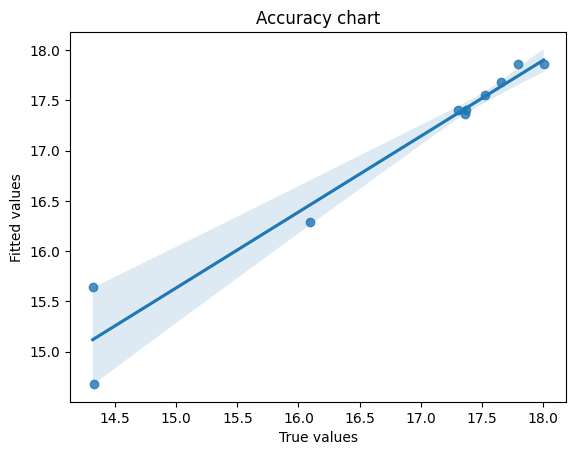

In [93]:
outliers_model_sklearn = LinearRegression().fit(X_train, y_train) # outliers sklearn model

y_pred = outliers_model_sklearn.predict(X_test) # store the fitted y(10 rows)

model_performance(y_pred, y_test, X_train, y_train, outliers_model_sklearn) # Show the model performance using test data(10 rows)

- The model is slight stable for outliers real estates(Extreme, prices, and sqm), good MAE, and RMSE, but high compared the non-outliers data due to outliers data have a very high prices

#### Random forest, and decision tree models

##### Decision tree model

Decision Tree Performance:
Final model metrics:
MAE     0.219932
RMSE    0.406522
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.80514113 0.92733247 0.92799938 0.87680278 0.71331595]


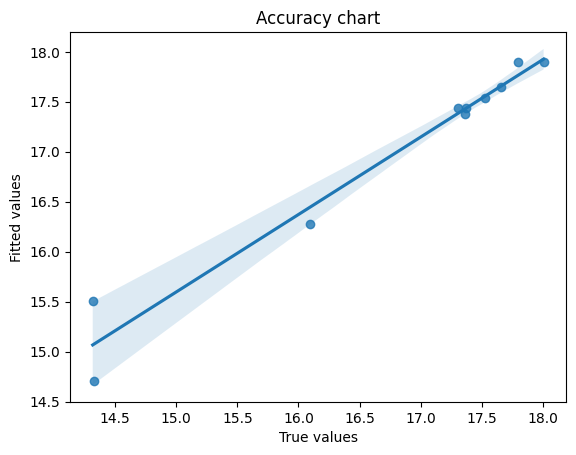

In [94]:
outliers_dt_model = decision_tree(X_train, X_test, y_test) # decision tree model of outliers data

- The model performance is moderate, good MAE, and RMSE, but high compared the non-outliers data due to outliers data have a very high prices

##### Random forest model


Random Forest Performance:
Final model metrics:
MAE     0.263352
RMSE    0.480248
Name: Metrics, dtype: float64
Cross validation score of the seen data:
[0.87607352 0.90681909 0.94978333 0.92496562 0.9159624 ]


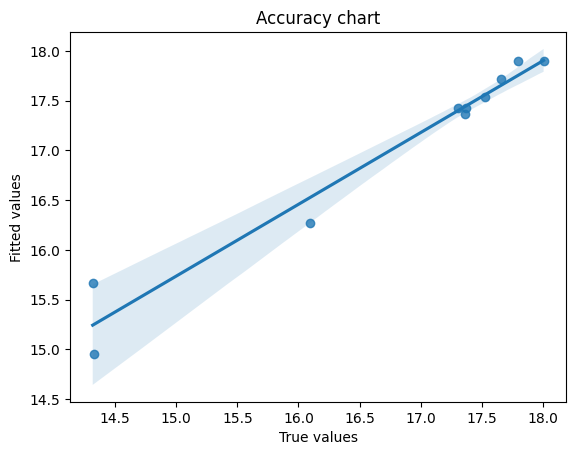

In [95]:
rf_outliers_model = random_forest(X_train, X_test, y_test) # Random forest model of outliers data

- The most stable model performance compared to the other models, with the highest MAE, RMSE, but the best model performance

#### summary:

The final best model is the random forest model due to stability, and low MAE, RMSE in outliers models like non-outliers models

## Summary:

- The best model in both outliers, and non_outliers is random forest model
- The number of features of outliers model is less than the outliers model due to high Vifs, and p-values
- The non-outliers models shows a stable performance, good MAE, RMSE, but outliers models shows a slightly stable models, good MAE, RMSE due to the shocks in the data
- The non-outliers model explained $\approx$ 80% of the data, but the outliers model explained $\approx$ 96% of the data due to the small number of observation compared to the non-outliers number of observations 
- Performed model specification, and model selection using GETS method
- Performed model evaluation to compare different models to get the best AIC, $R^2$, and stability